In [ ]:
#@markdown # Dependency collocation

# !pip3 install -U 'git+ssh://git@git.lwp.rug.nl:/team-data-science/2021/journalistic-feelings/labelstudioexport.git'
# !pip3 install -U 'git+ssh://git@git.lwp.rug.nl:/team-data-science/2021/journalistic-feelings/lexisnexis.git'
import os
import re
import sys
import json
import difflib
import warnings
import numpy as np
import pandas as pd
from scipy import sparse
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from multiprocessing import Pool
from sklearn.cluster import DBSCAN
from scipy.sparse import csr_matrix
from IPython.display import SVG, display
from sklearn.neighbors._base import EfficiencyWarning

import spacy
from spacy import displacy
from spacy.tokens import Token
from spacy.tokens import Span
import pandas as pd

from IPython.display import HTML

from scipy.sparse import csr_matrix
from sklearn.cluster import DBSCAN

tqdm.pandas()

os.environ['CUDA_VISIBLE_DEVICES'] = '1'

path = '/slow-data/journalisticfeelings/' #@param {"type": "string"}
os.chdir(path)
os.makedirs('./results/wordcollocation/', exist_ok=True)

articles_filename = './data/nexis-uni-export-unique.p3' #@param {"type": "string"}

personal_annotations_path = './data/nexis-uni-export-personal-pronoun-annotations.json'  #@param {"type": "string"}

section_groups_path = 'data/secties.xlsx' #@param {"type": "string"}

In [52]:
#@markdown # Load articles

articles = pd.read_pickle(articles_filename)

In [53]:
#@markdown # Load annotations

with open(personal_annotations_path) as f:
  personal_annotations = json.load(f)

personal_annotations = pd.Series(personal_annotations)

annotation_results = personal_annotations.str['annotations']
annotation_results = annotation_results.apply(lambda annotations: pd.DataFrame([
    dict(**annotation['value'], type=annotation['to_name'])
    for annotation in annotations[0]['result']]
))
assert annotation_results.apply(lambda labels: labels['type'].isin(['title']).sum() == 1).all(), "Unannotated or multiply-annotated articles"

personal_labels = annotation_results.apply(lambda labels: labels[labels['type'].isin(['title'])]['choices'].iloc[0])
assert (personal_labels.str.len() == 1).all(), "Ambiguously annotated personal/non-personal"
personal_labels = personal_labels.str[0]

# Articles annotated to contain personal pronouns referring to the author
personal_articles = articles.set_index(['zip', 'docx']).join(
  # Only select articles with a 'PERSONAL' annotation.
  personal_annotations[
    personal_labels.isin(['PERSONAL'])
  ].str['data'].apply(pd.Series)[['zip', 'docx']].set_index(['zip', 'docx']),
  how='inner')

token_labels = annotation_results[
    personal_labels.isin(['PERSONAL'])
].apply(lambda labels: labels[~labels['type'].isin(['title'])])

assert token_labels.apply(lambda labels: labels['paragraphlabels'].str.len().max()).max() == 1
assert token_labels.apply(lambda labels: (labels['start'] == labels['end']).all()).max()

personal_paragraphs = personal_articles['body'].explode().reset_index()
personal_paragraphs = personal_paragraphs.set_index([
    'zip', 'docx', personal_paragraphs.groupby(['zip', 'docx']).cumcount().rename('paragraph')])

personal_tokens = annotation_results[
    personal_labels.isin(['PERSONAL'])
].apply(lambda labels: labels[~labels['type'].isin(['title'])])
personal_tokens = personal_tokens.apply(lambda labels: labels[
    labels['paragraphlabels'].str[0] == 'PERSONAL'
  ][['start', 'startOffset', 'endOffset', 'text']].astype(
      {'start': int, 'startOffset': int, 'endOffset': int}
      ).rename({'start': 'paragraph', 'startOffset': 'start', 'endOffset': 'end'}, axis=1))
personal_tokens.index = [
  personal_annotations[personal_labels.isin(['PERSONAL'])].str['data'].str['zip'],
  personal_annotations[personal_labels.isin(['PERSONAL'])].str['data'].str['docx']
]
personal_tokens = pd.concat(personal_tokens.tolist(), keys=personal_tokens.index, names=['zip', 'docx']).reset_index(2, drop=True)
personal_tokens = personal_tokens.set_index('paragraph', append=True)
personal_tokens.sort_index(inplace=True)

personal_tokens = personal_tokens[personal_tokens.reset_index('paragraph').index.isin(personal_articles.index)]

personal_tokens['type'] = personal_tokens['text'].isin(['me', 'Ik', 'ik', 'mijn', 'mij', 'mezelf', 'Mijn', 'Mij', 'IK',
'MIJN', 'Me', 'zelf', 'mijne', 'Ikzelf', 'ikzelf', '', 'ME']).replace({True: 'ik', False: 'we'})

pd.DataFrame({'words': personal_tokens.groupby('type')['text'].apply(lambda x: ';'.join(set(map(str.lower, x))))})

,words
type,
ik,;ik;mij;mijn;mijne;me;zelf;ikzelf;mezelf
we,onszelf;we;ons;wij;onze


In [54]:
#@markdown # Helper function to find personal contexts

def personal_context(source_token, dependencies):
  """ Returns all dependency relations of a type in  `dependencies` between the
  personal pronoun `source_token` and its children. `obl` relations are returned
  as the entire subtree."""
  # Create a pronoun context with the children that have a particular relation to the pronoun.
  pronoun_rel = {'source:' + source_token.pos_: source_token.lemma_}
  for token in source_token.children:
    if token.dep_ not in dependencies:
      continue

    # For obl (oblique nominal, e.g. a noun phrase) dependency relation, add
    # the entire subtree as a string
    if token.dep_ == 'obl':
      pronoun_rel[token.dep_] = pronoun_rel.get(token.dep_, [])
      pronoun_rel[token.dep_].append(''.join(word.text + word.whitespace_ for word in token.subtree))
    # For other relations, only add that token's lemma (e.g cannonical form, is -> zijn)
    else:
      pronoun_rel[token.dep_] = pronoun_rel.get(token.dep_, [])
      pronoun_rel[token.dep_].append(token.lemma_)
  return pd.Series(pronoun_rel)


def personal_contexts(paragraph, dependencies):
  """ Returns a function that determines the personal contexts of a provided
  paragraph, where `pronouns` are pronous to look for, and `dependencies` lists
  child relations that are relevant for this context."""
  # Nested function to allow for specifying pronouns and dependencies first.
  
  return pd.DataFrame([
    # Fetch personal context for tokens which are a personal pronoun.
    pd.concat([
        personal_context(source_token, dependencies),
        pd.Series({'sentence': i, 'text': str(sentence)})
    ])
    for i, sentence in enumerate(paragraph.sents)
    for source_token in sentence
    if any(token._.personal for token in source_token.children)
  ])


def parse_deps_pronoun_contexts(sentence, pronouns, dependencies):
  """ Only show relations of pronoun contexts in `spacy.displacy.render` """
  sentence = nlp(sentence)
  
  return {
    'words': [
      {'text': token.text, 'tag': token.pos_, 'lemma': ''}#token.lemma_}
      for token in sentence
    ],
    'arcs':  [
      {'start': min(source_token.i, child_token.i), 'end': max(source_token.i, child_token.i), 'dir': ["left", "right"][int(source_token.i < child_token.i)],
       'label': child_token.dep_}
      for source_token in sentence
      if any(token.text.lower() in pronouns for token in source_token.children)
      for child_token in source_token.children
      if child_token.dep_ in dependencies
         or child_token.text.lower() in pronouns
    ],
    'settings': {'lang': 'nl', 'direction': 'ltr'},
  }

In [55]:
#@markdown # Run spacy dependency detection and mark personal tokens and sentences

model = "nl_core_news_sm" #@param {"type": "string"}

if 'nlp' not in globals() or model_loaded != model:
  try:
    nlp = spacy.load(model)
    model_loaded = model
  except OSError:
    !python -m spacy download {model}
    nlp = spacy.load(model)
    model_loaded = model

relations = "nsubj;obj;fixed;aux;mod;obl;obl:agent;nsubj:pass;xcomp;nmod:poss;iobj;advmod;cop" #@param {"type": "string"}
relations = relations.split(';')

if 'nlp' not in personal_paragraphs.columns:
  personal_paragraphs['nlp'] = personal_paragraphs['body'].progress_apply(
      nlp, disable=["ner"])

Token.set_extension('personal', default=False, force=True)
Span.set_extension('personal', default=False, force=True)

for name, doc in tqdm(personal_paragraphs['nlp'].iteritems(),
                      total=len(personal_paragraphs)):
  if name not in personal_tokens.index:
    continue
  tokens = personal_tokens.loc[name]
  matched = pd.Series(False, index=tokens.index)
  for sentence in doc.sents:
    sentence._.personal = False
    for token in sentence:
      start = token.idx
      end = start + len(token)
      matches = (tokens[['start', 'end']] == [start, end]).max(1)
      matched |= matches
      token._.personal = matches.any()
      sentence._.personal |= matches.any()
  assert matched.all()

personal_contexts_ = personal_paragraphs['nlp'].progress_apply(
    personal_contexts, dependencies=relations)
personal_contexts__ = pd.concat(personal_contexts_.tolist(), keys=personal_contexts_.index, names = ['zip', 'docx', 'paragraph'])
personal_contexts__['sentence'] = personal_contexts__['sentence'].astype(int)
personal_contexts__ = personal_contexts__[['text'] + sorted(set(personal_contexts__.columns) - {'text'}, key=lambda x: (not x.startswith('source:'), x))].set_index('sentence', append=True)
personal_contexts___ = personal_contexts__.applymap(lambda x: x if x==x else ['']).applymap(lambda x: ';'.join(x) if type(x) == list else x).reset_index(3, drop=True)


  0%|          | 0/64659 [00:00<?, ?it/s]

  0%|          | 0/64659 [00:00<?, ?it/s]

  0%|          | 0/64659 [00:00<?, ?it/s]

In [ ]:
#@markdown # Export contexts

personal_contexts___.set_index('text', append=True).to_excel('results/wordcollocation/personal-contexts.xlsx', freeze_panes=(1, 5))

In [80]:
#@markdown # Export pronoun statistics

article_metadata = articles.set_index(['zip', 'docx'])[[
    'paper', 'date', 'title', 'section group', 'page', 'Length', 'Byline', 'Dateline', 'Load-Date']]
article_metadata.rename({'section group': 'section'}, axis=1, inplace=True)
article_metadata['title'] = article_metadata['title'].str.join(' ')

if 'tokenized' not in globals():
  tokenized = articles.set_index(['zip', 'docx'])['body'].explode().progress_apply(
      nlp, disable=['parser', 'lemmatizer', 'attribute_ruler', 'ner']
  )
  # unique_tokenized = tokenized[tokenized.index.isin(articles.groupby(['zip', 'docx']).first().index)]
  # tokens = unique_tokenized.progress_apply(lambda x: [x.text for x in x]).explode()
  tokens = tokenized.progress_apply(lambda x: [x.text for x in x]).explode()
  unique_tokens = pd.Series(tokens.str.lower().unique())

  n_words = (
    # ~unique_tokenized.progress_apply(
    ~tokenized.progress_apply(
      lambda x: [x.pos_ for x in x]
        ).explode().isin(
          {'PUNCT', 'SPACE', 'SYM'})
  ).groupby(['zip', 'docx']).sum()

  # n_tokens = unique_tokenized.str.len().groupby(['zip', 'docx']).sum()
  n_tokens = tokenized.str.len().groupby(['zip', 'docx']).sum()

if 'pronouns_' not in globals():
  pronouns_ = {}
  for pronoun, exp in {
    'ik': pd.Series("ik;ik;me;me;mij;mij;mezelf;mijn;m'n;mijzelf".split(';')),
    'we': pd.Series("we;wij;ons;onze".split(';'))}.items():
    exp = exp.apply(re.escape).str.replace('e', '[eé]').str.replace('i', '[ií]').str.replace('o', '[oó]').str.replace("'", "['’]")
    exp = re.compile('^(?:' + '|'.join('[-./²⅝]?' + exp + '[-./²⅝]?') + ')$')
    pronouns = set(unique_tokens[unique_tokens.str.contains(exp)])
    pronouns = tokens[tokens.str.lower().isin(pronouns)]
    counts = pronouns.groupby(['zip', 'docx']).apply(len)
    pronouns = pronouns.groupby(['zip', 'docx']).apply(';'.join)
    pronouns_[pronoun] = pd.DataFrame({'count': counts, 'pronouns': pronouns})

pronoun_use = pd.concat([
  pd.concat(pronouns_, axis=1),
  personal_tokens.groupby(['zip', 'docx', 'type']).apply(len).rename('count').reset_index().pivot(['zip', 'docx'], 'type').fillna(0).astype(int).swaplevel(0, 1, 1),
  personal_tokens.groupby(['zip', 'docx', 'type'])['text'].apply(';'.join).rename('pronouns').reset_index().pivot(['zip', 'docx'], 'type').fillna('').swaplevel(0, 1, 1)
], keys = ['not personal', 'personal', 'personal'], axis=1).T.sort_index().T

metadata = pd.concat([
    pd.concat([pd.concat([pd.concat([
      pd.DataFrame({'is personal': True}, index=personal_articles.groupby(['zip', 'docx']).first().index),
      pd.DataFrame({'# words': n_words}),
      pd.DataFrame({'# tokens': n_tokens}),
      article_metadata], axis=1)], keys=[''], axis=1)], keys=[''], axis=1),
    pronoun_use
], axis=1)

for personal, pronoun, value in pronoun_use.columns:
  metadata[(personal, pronoun, value)].fillna(
          {'count': 0, 'pronouns': ''}[value], inplace=True)
  metadata[(personal, pronoun, value)] = metadata[(personal, pronoun, value)].astype({'pronouns': str, 'count': int}[value])

metadata.iloc[
    :, metadata.columns.get_loc(('','', 'is personal'))
].fillna(False, inplace=True)
metadata.sort_index(inplace=True)

metadata[('', '', 'n words')] = tokenized.apply(len).groupby(['zip', 'docx']).sum()

weekdays = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
metadata[('', '', 'day of week')] = pd.to_datetime(metadata.iloc[
    :, metadata.columns.get_loc(('','', 'date'))
]).dt.dayofweek.astype(int).apply(weekdays.__getitem__)

metadata[('', '', 'year')] = pd.to_datetime(metadata.iloc[
    :, metadata.columns.get_loc(('','', 'date'))
]).dt.year

metadata[('', '', 'paper')].replace({'AD/Algemeen Dagblad': 'Algemeen Dagblad'}, inplace=True)
metadata = metadata.T.sort_index().T
metadata[('',   '', 'is personal')] = metadata[('',   '', 'is personal')].astype(bool)
metadata.to_excel('results/wordcollocation/article-metadata.xlsx', freeze_panes=(4, 2))

# For section clustering by Kim
# sections[0].dropna().value_counts().reset_index().rename({'index': 'sectie', 0: 'count'}, axis=1).to_excel('secties.xlsx', index=False)

  0%|          | 0/573097 [00:00<?, ?it/s]

  0%|          | 0/573097 [00:00<?, ?it/s]

  0%|          | 0/573097 [00:00<?, ?it/s]

# Plots

unfinished, unstable and unpolished plots for Kim to give a quick judgement.

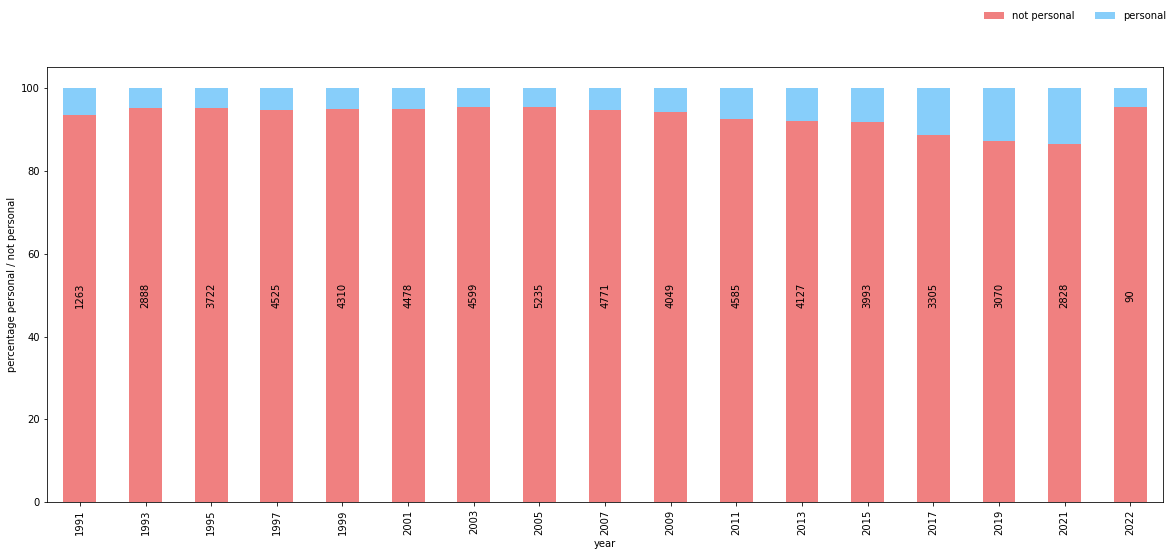

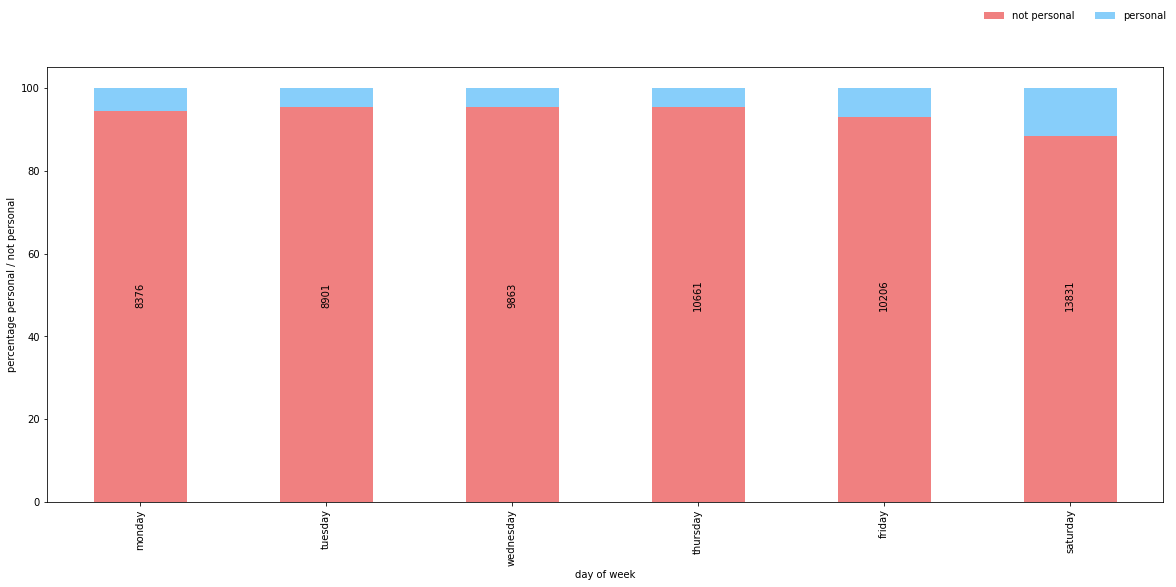

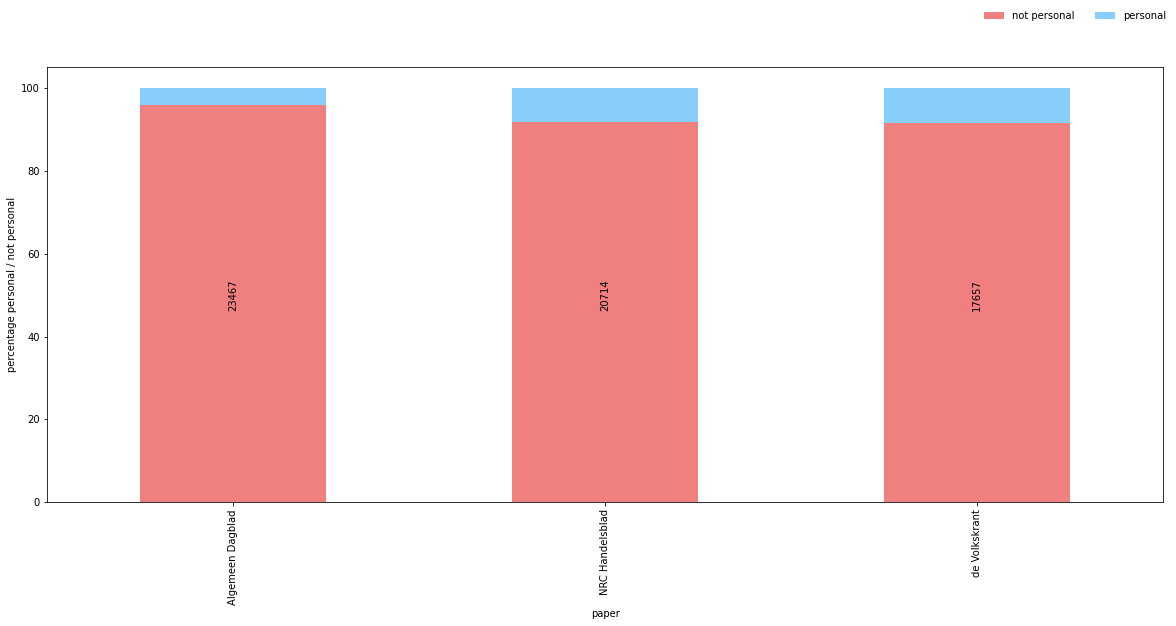

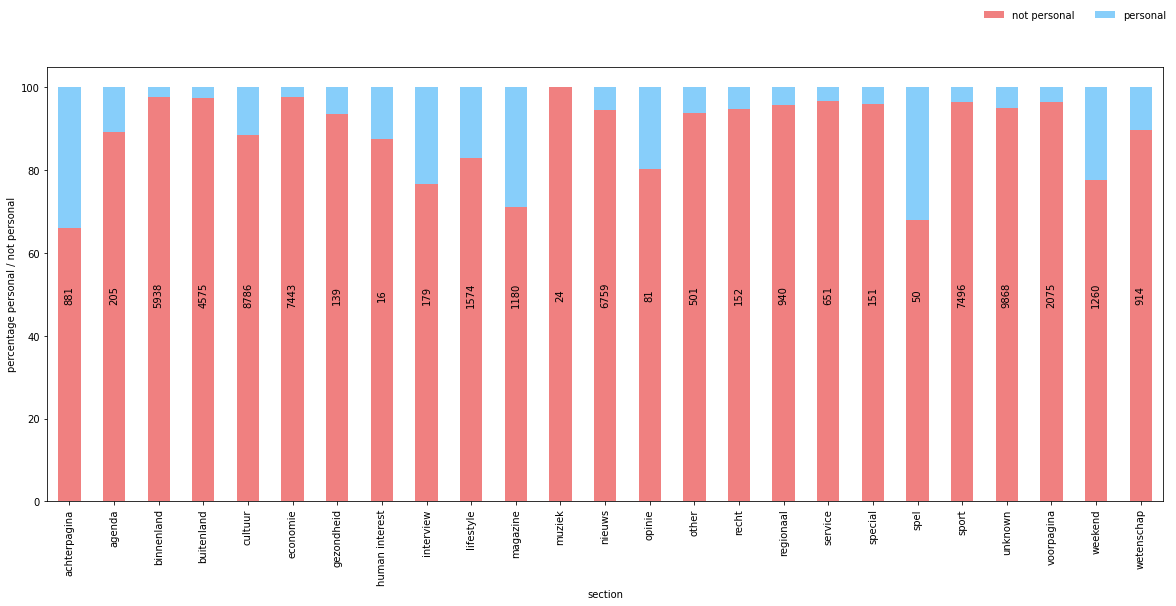

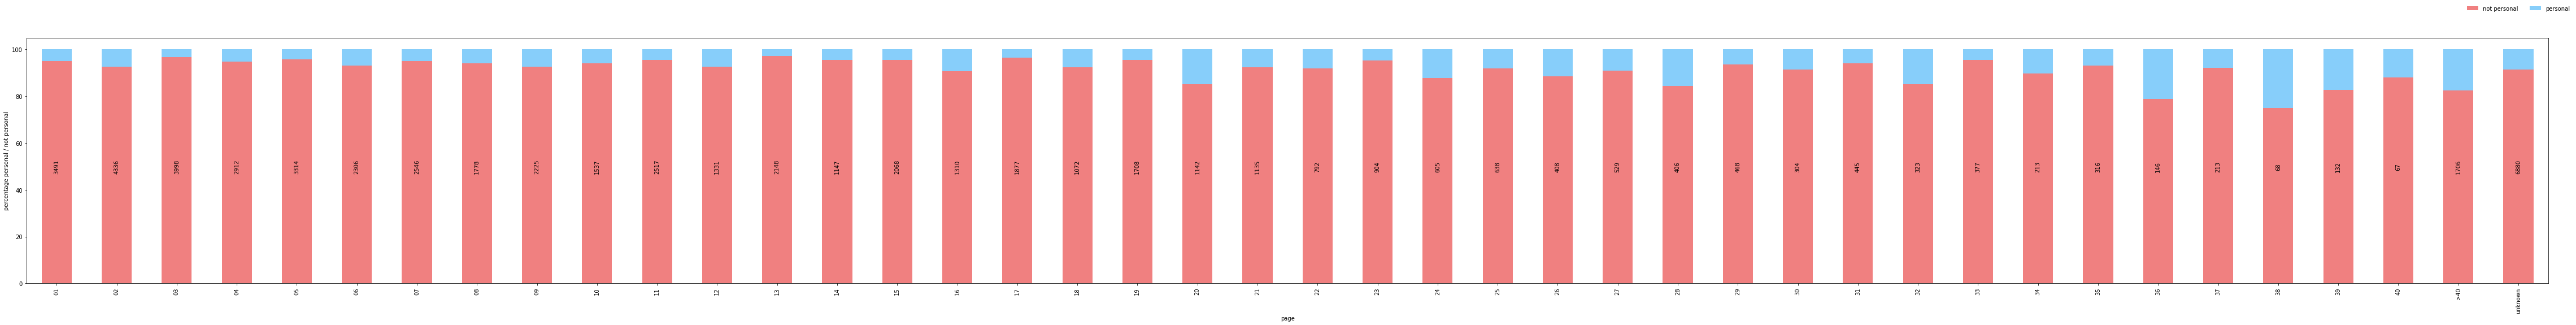

In [81]:
#@markdown # Personal vs. not personal

for variable in ['year', 'day of week', 'paper', 'section', 'page']:
  fig, ax = plt.subplots(1,1, figsize=(80 if variable in{'page', 'sectie'} else 20, 8))
  aggregation = metadata[('', '')].groupby([variable, 'is personal']).apply(len).reset_index().pivot(variable, 'is personal', 0).rename({False: 'not personal', True: 'personal'}, axis=1)
  if variable == 'day of week':
    aggregation = aggregation.iloc[aggregation.index.to_frame().iloc[:, 0].apply(weekdays.index).argsort()]
  if variable == 'year':
    aggregation.sort_index(key=lambda x: x.to_series().apply(lambda x: {'unknown': int(1e10)}.get(x,x)), inplace=True)
  if variable == 'sectie':
    aggregation.sort_index(inplace=True)
  if variable == 'sectie':
    aggregation['total'] = aggregation.sum(1)
    aggregation.loc['other', 'total'] = -1
    aggregation.loc['unknown', 'total'] = -2
    aggregation.sort_values('total', inplace=True, ascending=False)
    aggregation = aggregation.drop('total', axis=1)
  # aggregation.index = aggregation.index.to_series().astype(str) + ' (' + aggregation.sum(1).fillna(0).astype(int).astype(str) + ')'

  for x, count in enumerate(aggregation.sum(1).fillna(0).astype(int).astype(str)):
    plt.text(x, 50, f'{count}', rotation=90, ha='center', va='center')

  ax = (100 * aggregation.div(aggregation.sum(1), axis=0)).plot(kind='bar', stacked=True, color=['lightcoral', 'lightskyblue'], ax=ax)
  ax.legend(loc='upper right', bbox_to_anchor=(1.0105, 1.15), ncol=2, frameon=False)
  ax.set_ylabel('percentage personal / not personal')
  plt.savefig(f'results/wordcollocation/personal-occurrence-{variable}.png')

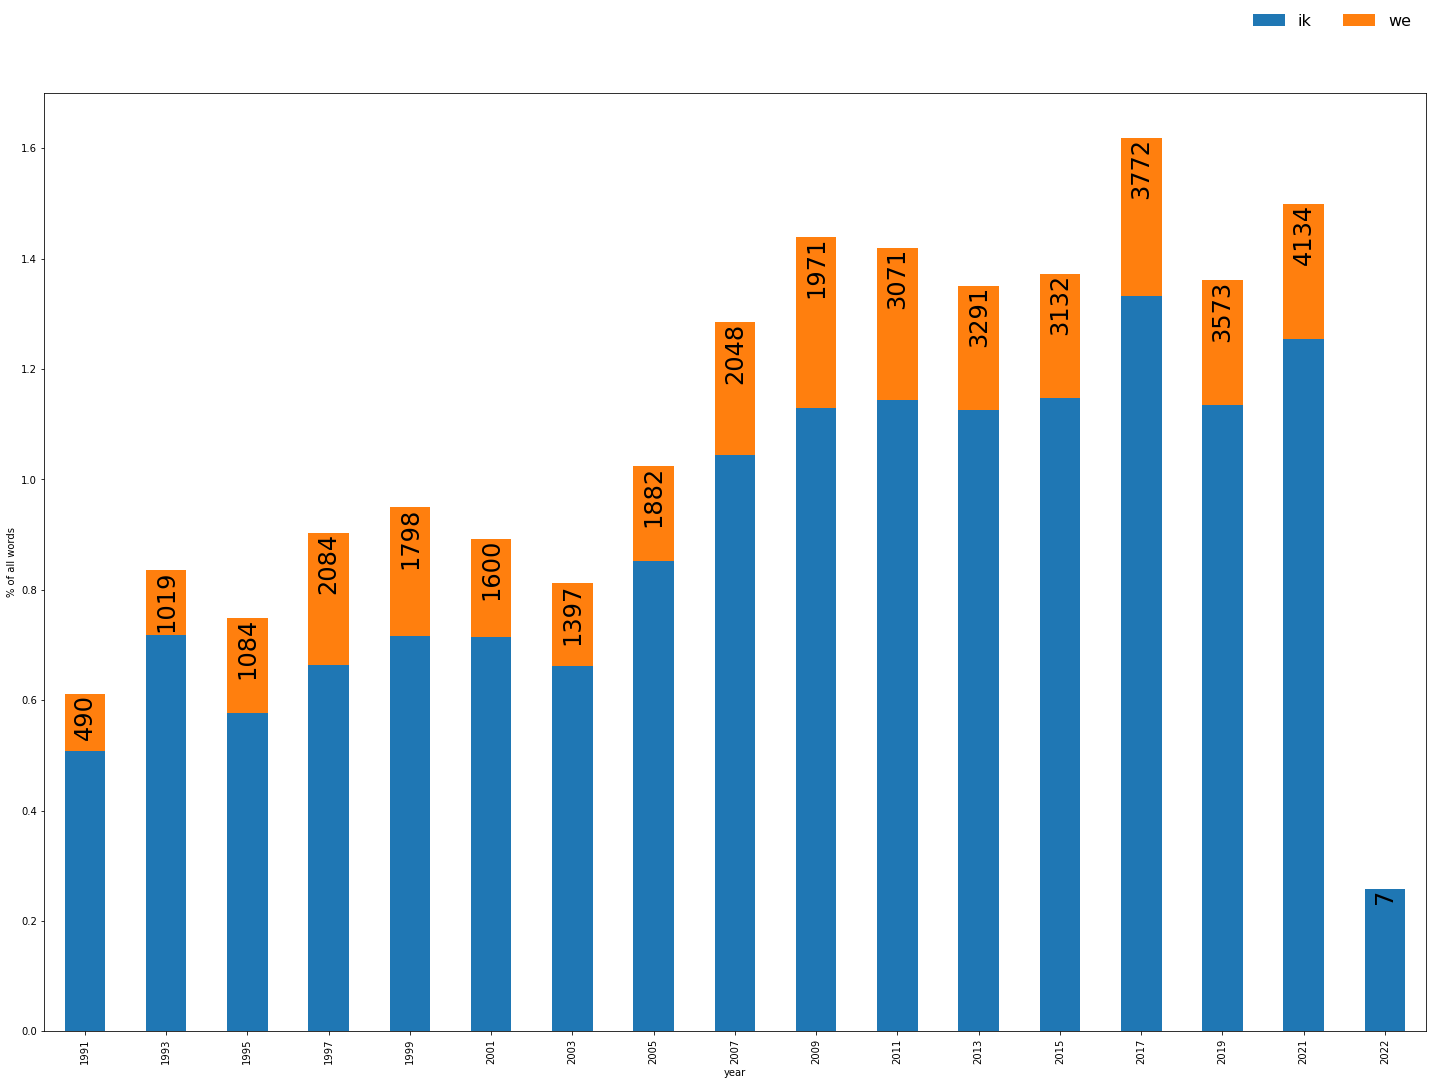

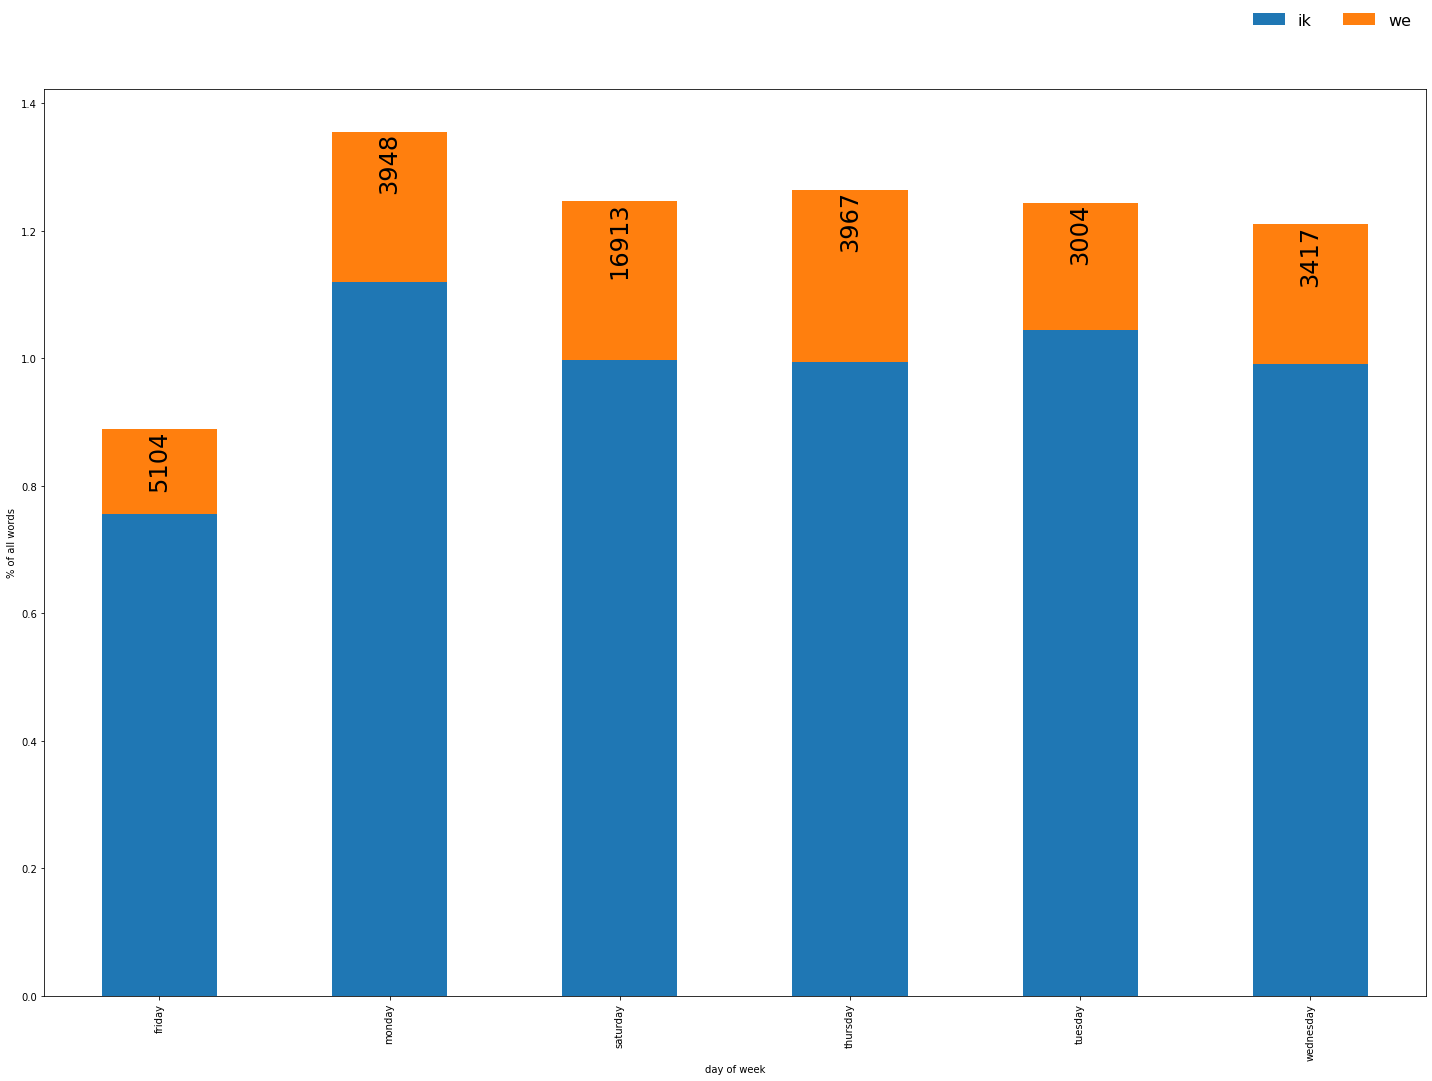

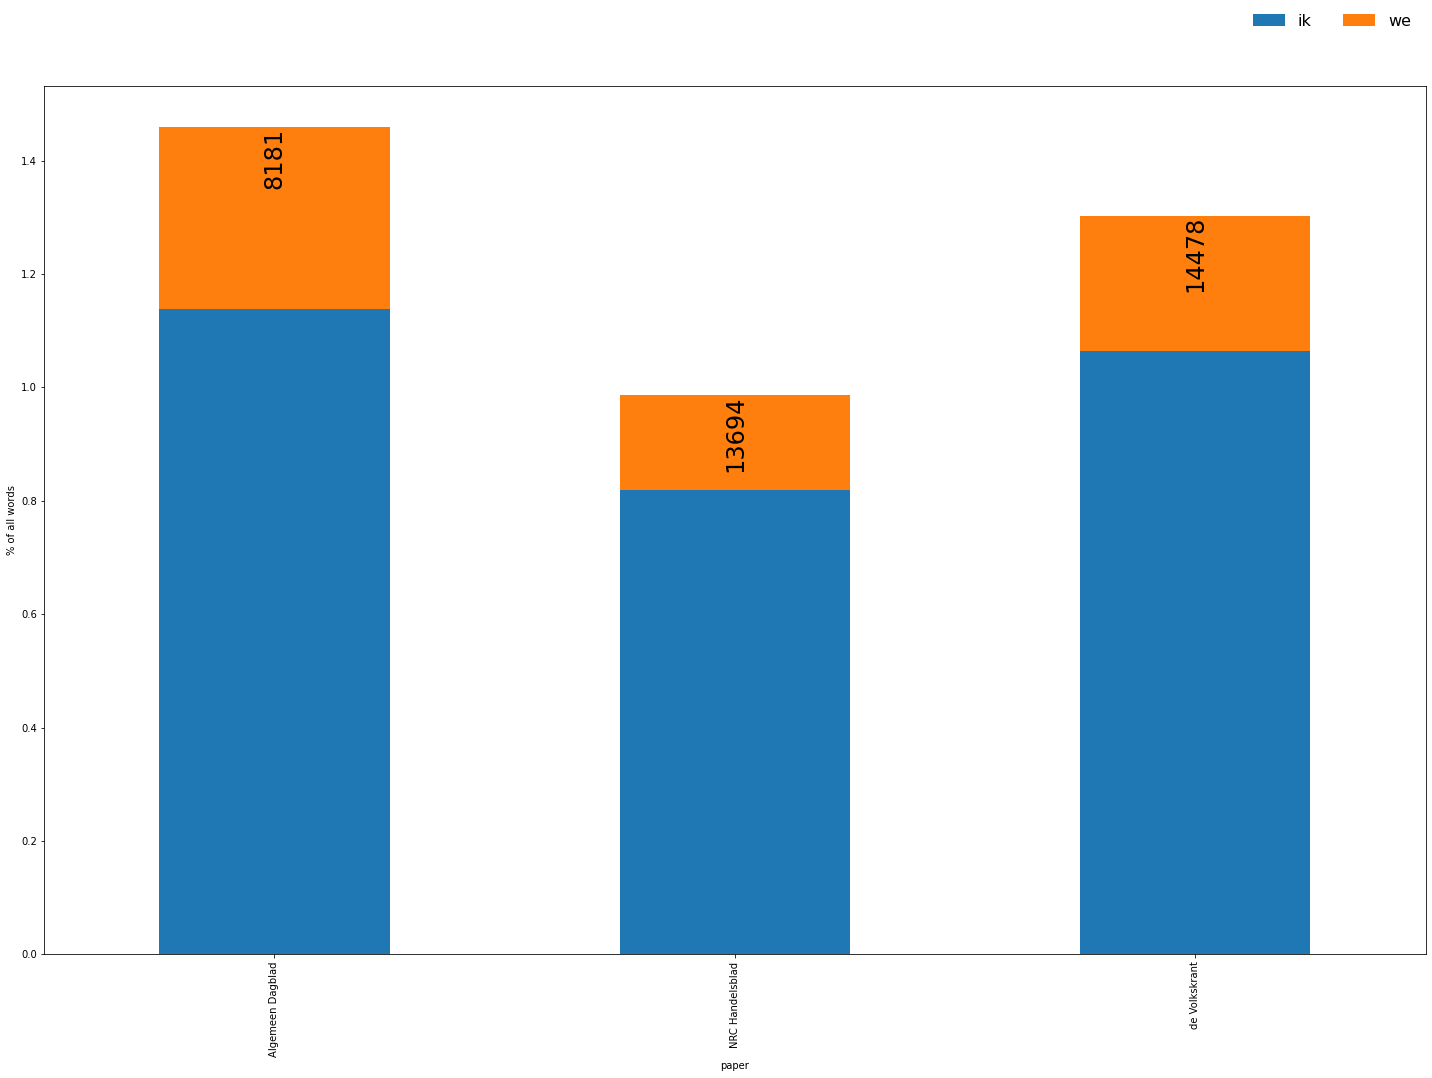

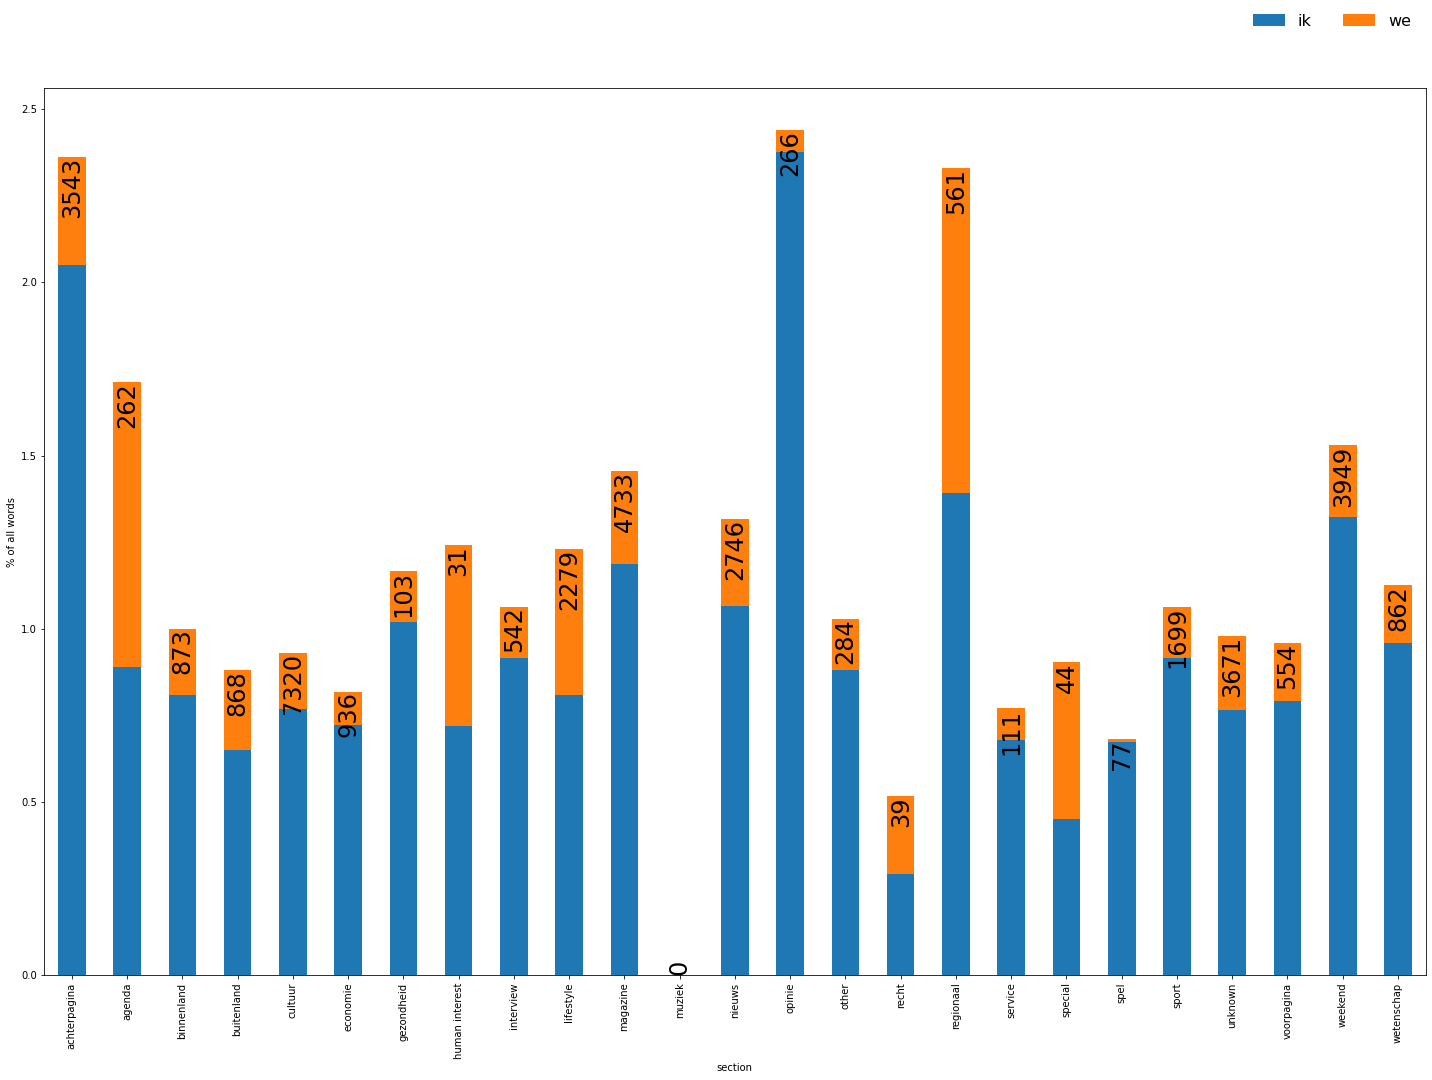

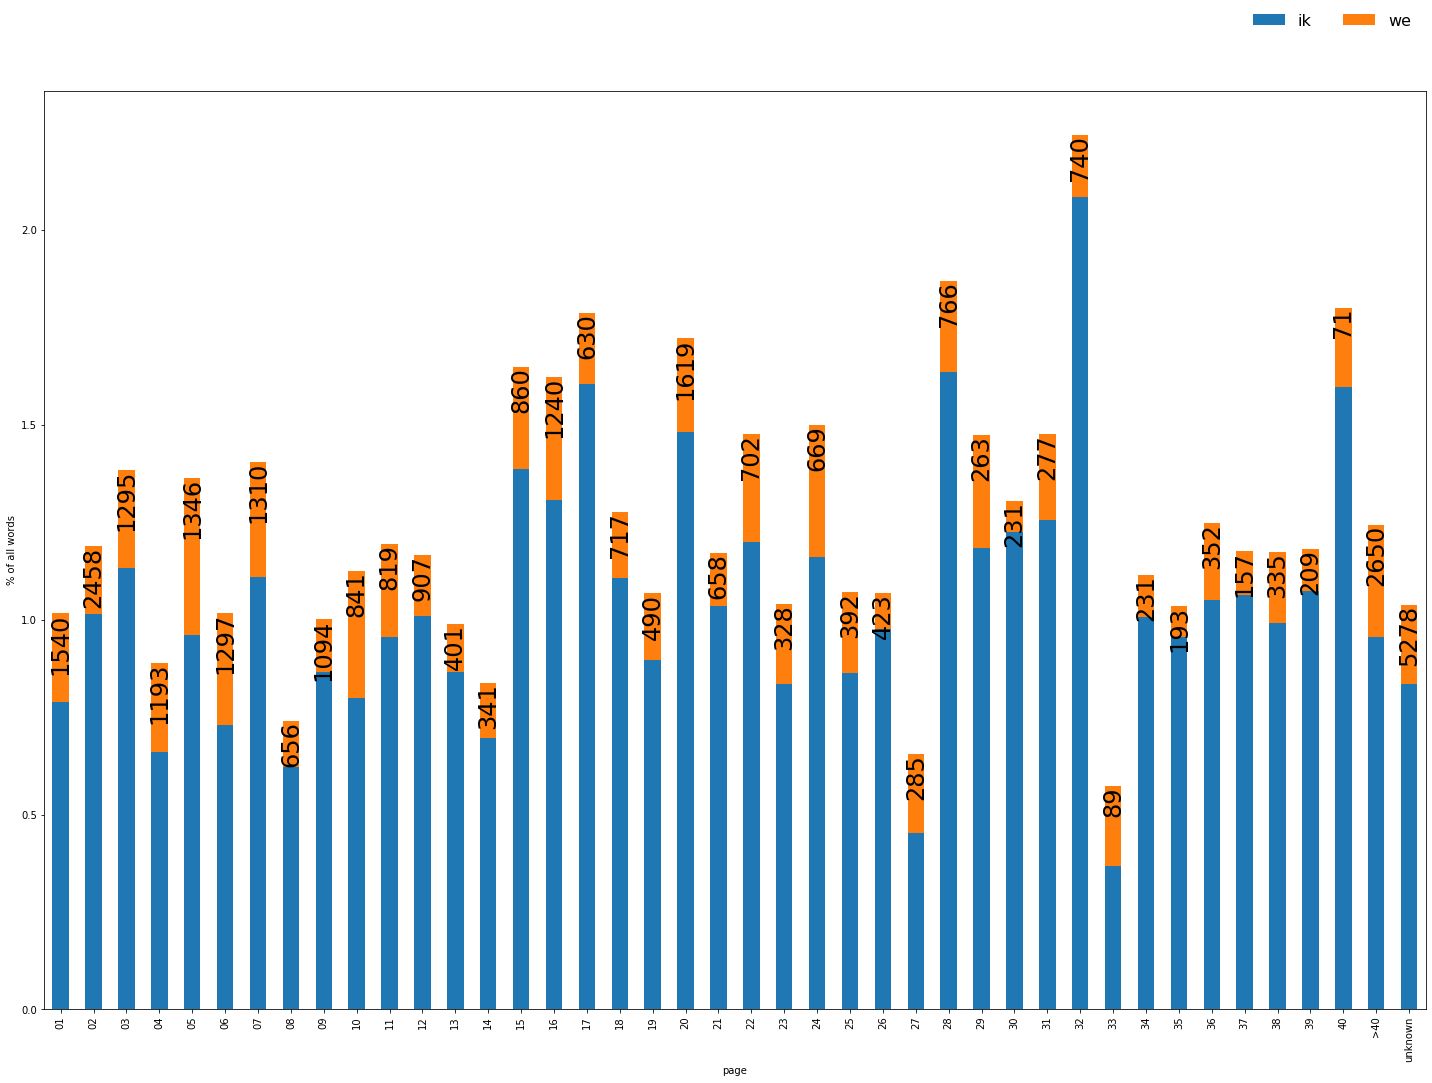

In [82]:
#@markdown # personal ik vs. we within personal articles

for variable in ['year', 'day of week', 'paper', 'section', 'page']:
  pronoun_counts = metadata.loc[:, ('personal', ['ik', 'we'], 'count')].groupby(metadata[('', '')][variable]).sum()
  pronoun_counts.columns = ['ik', 'we']
  words = metadata[
    metadata[('', '', 'is personal')]
  ][('', '', '# words')].groupby(metadata[('', '')][
      variable
  ]).sum()
  pronoun_percentages = pronoun_counts.apply(lambda x: 100 * x / words)
  fig, ax = plt.subplots(1, 1, figsize=(20, 15))
  pronoun_percentages.plot(kind='bar', stacked=True, ax=ax)
  ax.legend(loc='upper right', bbox_to_anchor=(1, 1.1), ncol=2, frameon=False, fontsize=16)
  ax.set_ylabel('% of all words')
  ymax = plt.ylim()[1]
  for x, count in enumerate(pronoun_counts.sum(1).astype(int).astype(str)):
    y = pronoun_percentages.iloc[x].sum()
    if y < 0.1 * ymax:
      ax.text(x, 0.001, f'{count}', rotation=90, ha='center', va='bottom', fontsize=24)
    else:
      ax.text(x, y, f'{count}', rotation=90, ha='center', va='top', fontsize=24)
  plt.tight_layout()
  plt.savefig(f'results/wordcollocation/pronoun-occurrence-{variable}.png')